In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix



In [2]:
df=pd.read_csv("C:/Users/hafee/OneDrive/Desktop/Desktop/AI-Based Tropical Cyclone Forecasting/cyclone_dataset.csv")
df

,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
0,27.498160,1008.521429,89.279758,13.979877,0.000020,8.119890,76.137625,1.366176,1,1
1,28.404460,1001.242177,60.823380,19.548648,0.000084,9.246782,131.821235,0.683405,1,1
2,27.216969,995.742693,77.277801,9.368437,0.000063,7.789877,181.465092,0.866362,1,1
3,27.824280,1003.555279,67.986951,12.713517,0.000061,5.929008,323.395183,0.670524,1,1
4,26.260206,1008.466566,98.625281,17.125960,0.000034,6.953442,357.904862,0.940152,1,1
...,...,...,...,...,...,...,...,...,...,...
1995,24.444059,1019.783538,58.691379,15.306127,0.000034,22.229769,2769.879093,1.487565,0,0
1996,23.049400,1017.971950,74.193806,10.104250,0.000047,25.230303,3533.586214,1.855625,0,0
1997,23.736830,1020.874352,38.880991,13.183351,0.000033,32.402860,4472.888270,1.643740,0,0
1998,24.203914,1008.284827,79.000021,16.393914,0.000037,25.639636,3081.710478,1.393481,0,0


In [3]:
print(df.describe())

       Sea_Surface_Temperature  Atmospheric_Pressure     Humidity  \
count              2000.000000           2000.000000  2000.000000   
mean                 26.011795           1003.390161    67.204883   
std                   2.695970             12.021871    17.727458   
min                  20.014982            980.033363    30.015487   
25%                  24.074962            994.466175    55.188218   
50%                  26.662512           1004.708218    68.635351   
75%                  28.049755           1012.159534    78.975341   
max                  29.997655           1024.986477    99.955704   

        Wind_Shear    Vorticity     Latitude  Ocean_Depth  \
count  2000.000000  2000.000000  2000.000000  2000.000000   
mean     16.129547     0.000039    20.057002  1433.043855   
std       6.221843     0.000026     7.528196  1524.801300   
min       5.010753     0.000001     5.004541    50.005236   
25%      11.413949     0.000018    15.222078   261.794807   
50%      15.

In [4]:
df.isna().sum()

Sea_Surface_Temperature     0
Atmospheric_Pressure        0
Humidity                    0
Wind_Shear                  0
Vorticity                   0
Latitude                    0
Ocean_Depth                 0
Proximity_to_Coastline      0
Pre_existing_Disturbance    0
Cyclone                     0
dtype: int64

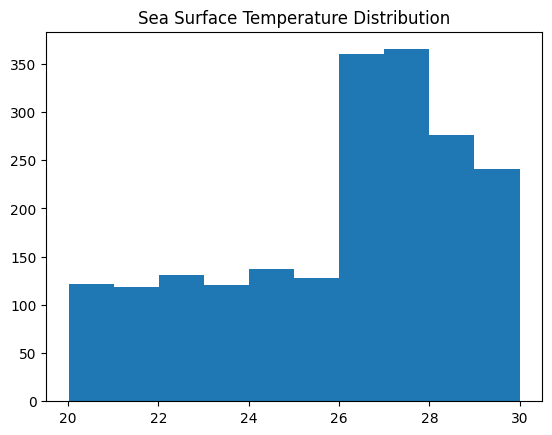

In [5]:
plt.hist(df['Sea_Surface_Temperature'],bins=10)
plt.title('Sea Surface Temperature Distribution')
xlabel='Temperature'
ylabel='Frequency'
plt.show()

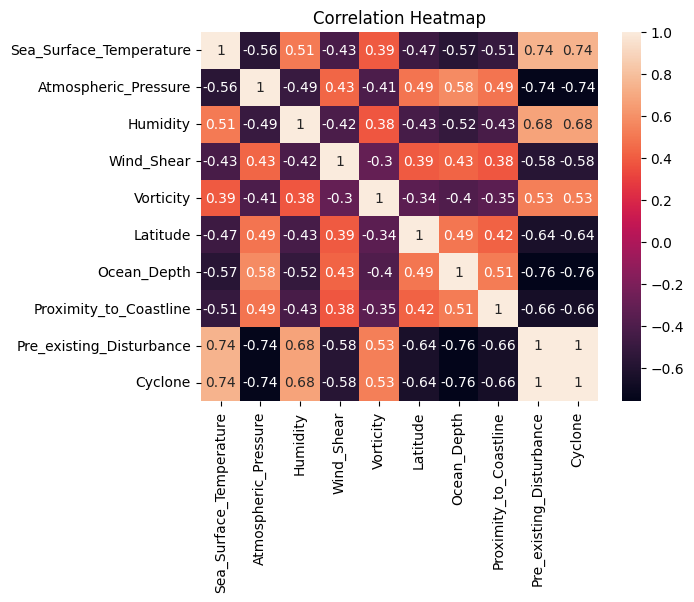

In [6]:
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

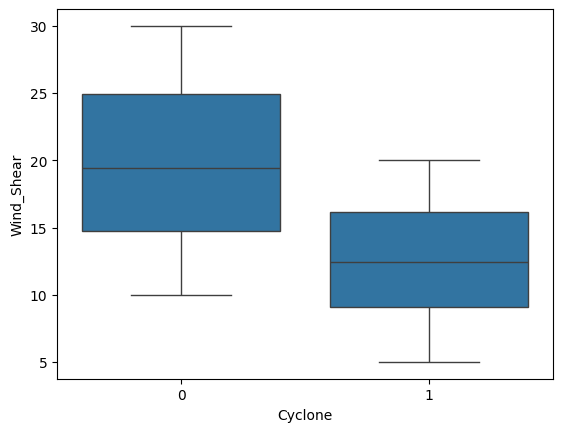

In [7]:
sns.boxplot(x='Cyclone',y='Wind_Shear',data=df)
plt.show()

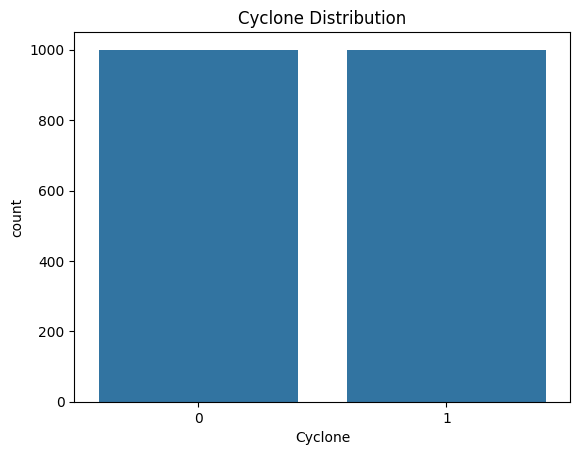

In [8]:
sns.countplot(x='Cyclone',data=df)
plt.title("Cyclone Distribution")
plt.show()

In [9]:
df.drop(['Pre_existing_Disturbance','Vorticity'],axis=1,inplace=True)

In [10]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [11]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search=GridSearchCV(estimator=RandomForestClassifier(),
                        param_grid=param_grid,
                        cv=5,
                        scoring='accuracy')
grid_search.fit(x_train,y_train)
print('Best Parameter Found:')
print(grid_search.best_params_)
print('cv_score:',grid_search.best_score_)

Best Parameter Found:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
cv_score: 1.0


In [13]:
best_rf = grid_search.best_estimator_
best_rf.fit(x_train,y_train)

y_predict=best_rf.predict(x_test)
print('Accuracy_score : ',accuracy_score(y_test,y_predict))

print('\nClassification Report\n')
print(classification_report(y_test,y_predict))

Accuracy_score :  1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       199

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [14]:
print("Train Accuracy:", best_rf.score(x_train, y_train))
print("Test Accuracy:", best_rf.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


In [15]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [16]:
svm_param_grid={'C':[0.1,1,10,100],
                'kernel':['linear','rbf','poly'],
                'gamma':['scale',0.01,0.1,1]}

svm_grid_search=GridSearchCV(estimator=SVC(),
                            param_grid=svm_param_grid,
                            cv=5,
                            scoring='accuracy',
                            )

best_svm=svm_grid_search.fit(x_train_scaled,y_train)

svm_y_predict=best_svm.predict(x_test_scaled)
print('Best Parameter Found')
print(best_svm.best_params_)
print('Accuracy score :',accuracy_score(y_test,svm_y_predict))
print('\nConfusion Matrix\n')
print(confusion_matrix(y_test,svm_y_predict))
print('\nClassification Report\n')
print(classification_report(y_test,svm_y_predict))



Best Parameter Found
{'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Accuracy score : 1.0

Confusion Matrix

[[201   0]
 [  0 199]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       199

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [17]:
print("Train Accuracy:", best_svm.score(x_train_scaled, y_train))
print("Test Accuracy:", best_svm.score(x_test_scaled, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0
